# **Assignment 1: The Value of Time**

_______________________________________________________________________

## **Imports**

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from IPython.display import Markdown, display
from scipy.interpolate import CubicSpline
import matplotlib.colors as mcolors

np.seterr(divide='ignore', invalid='ignore')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Palatino"
})

## **Helper Functions**

In [42]:
# Define function to calculate residual between market dirty price and model dirty price given a YTM:

def residual(ytm, dirty_price, coupon_payment, face_value, terms_to_maturity):

    """Calculate residual = dirty price - DCF(ytm)

    Args:
        ytm (float): Yield to maturity as a decimal.
        dirty_price (float): Market dirty price of the bond.
        coupon_payment (float): Annual coupon payment of the bond.
        terms_to_maturity (array-like): Times from price observation date to each coupon payment date in years.
    Returns:
        float: Residual between market dirty price and discounted cash flow with given ytm.
    """
        
    # Calculate present value of coupon payments:
    PV_rem_coupons = np.sum((coupon_payment / 2) / (1 + ytm / 2) ** (2 * terms_to_maturity[:-1]))
    
    # Calculate present value of face value and final coupon:
    PV_face_value = (coupon_payment / 2 + face_value) / (1 + ytm / 2) ** (2 * terms_to_maturity[-1])
    
    # Calculate discounted cash flows with given ytm:
    disc_cf = PV_rem_coupons + PV_face_value
    
    return dirty_price - disc_cf

__________________________________

## **Read in and Preprocess Data**

Recall from Question 2.2 (a) that our chosen bonds are as follows:

CAN 0.25 Mar. 01, 26 

CAN 1.0 Sep. 01, 26

CAN 1.25 Mar. 01, 27

CAN 2.75 Sep. 01, 27

CAN 3.5 Mar. 01, 28

CAN 3.25 Sep. 01, 28

CAN 4.0 Mar. 01, 29

CAN 3.5 Sep. 01, 29

CAN 2.75 Mar. 01, 30

CAN 2.75 Sep. 01, 30

CAN 2.75 Mar. 01, 31


### **Preprocess Bond Specifications Data**

In [43]:
############### Clean bond specification data: ###############

# Read in bond specification data:
bond_spec_df = pd.read_csv('bond_spec_data.csv')

# Convert date columns to datetime:
for date_col in ['Maturity Date', 'Issue Date', 'Coupon Start Date', 'Final Coupon Date']:
    bond_spec_df[date_col] = pd.to_datetime(bond_spec_df[date_col])

# Convert percentage to decimals for coupon rates:
bond_spec_df['Coupon'] = bond_spec_df['Coupon'].str.rstrip('%').astype(float) / 100 

# Get ISIN of chosen bonds:
ISINs = bond_spec_df.loc[bond_spec_df["Maturity Date"].dt.month.isin([3, 9]) 
                         & (bond_spec_df['Maturity Date'].dt.year <= 2031), "ISIN"]

# Filter bond spec data for chosen ISINs:
bond_spec_df = bond_spec_df[bond_spec_df['ISIN'].isin(ISINs)]

# Keep only relevant columns:
spec_cols = ['ISIN',
             'Coupon',
             'Denomination',
             'Maturity Date',
             'Coupon Start Date',
             'Final Coupon Date']

bond_spec_df = bond_spec_df[spec_cols].reset_index(drop=True)

# Rename columns for clarity:
bond_spec_df = bond_spec_df.rename(columns={"Coupon": "Coupon Rate",
                                            "Denomination": "Face Value"})

# Add (annual) coupon payment amount column:
bond_spec_df.insert(loc=3, column='Coupon Payment', value=bond_spec_df['Coupon Rate'] * bond_spec_df['Face Value'])

display(Markdown("### **Bond Specification Data**"))
display(bond_spec_df)

### **Bond Specification Data**

,ISIN,Coupon Rate,Face Value,Coupon Payment,Maturity Date,Coupon Start Date,Final Coupon Date
0,CA135087L518,0.0025,1000,2.5,2026-03-01,2021-03-01,2026-02-28
1,CA135087L930,0.0100,1000,10.0,2026-09-01,2021-09-01,2026-08-31
2,CA135087M847,0.0125,1000,12.5,2027-03-01,2022-03-01,2027-02-28
3,CA135087N837,0.0275,1000,27.5,2027-09-01,2022-09-01,2027-08-31
4,CA135087P576,0.0350,1000,35.0,2028-03-01,2023-03-01,2028-02-29
5,CA135087Q491,0.0325,1000,32.5,2028-09-01,2023-09-01,2028-08-31
6,CA135087Q988,0.0400,1000,40.0,2029-03-01,2024-03-01,2029-02-28
7,CA135087R895,0.0350,1000,35.0,2029-09-01,2024-09-01,2029-08-31
8,CA135087S471,0.0275,1000,27.5,2030-03-01,2025-03-01,2030-02-28
9,CA135087T388,0.0275,1000,27.5,2030-09-01,2025-09-01,2030-08-31


### **Preprocess Bond Specifications Data**

In [44]:
############### Clean bond price data: ###############  

# Read in bond price data:
bond_price_df = pd.read_csv('bond_price_data.csv')

# Convert date column to datetime:
bond_price_df['date'] = pd.to_datetime(bond_price_df['date'])

# Filter price data for chosen ISINs:
bond_price_df = bond_price_df[bond_price_df['ISIN'].isin(ISINs)]

# Filter price data for final price in each day:
bond_price_df = bond_price_df[bond_price_df['date'].dt.hour > 20].reset_index(drop=True)

# Keep only relevant columns:
price_cols = ['ISIN', 'date', 'close']
bond_price_df = bond_price_df[price_cols].reset_index(drop=True)

# Rename columns for clarity:
bond_price_df = bond_price_df.rename(columns={"close": "Quoted Price",
                                              "date": "Date"})

# Add Clean Price column (Note: Clean Price = Quoted Price * Face Value / 100 as quoted price is quoted relative to par (face value)):
bond_price_df['Clean Price'] = bond_price_df['Quoted Price'] * bond_spec_df.set_index('ISIN').loc[bond_price_df['ISIN'], 'Face Value'].values / 100

display(Markdown("### **Bond Price Data**"))
display(bond_price_df)

### **Bond Price Data**

,ISIN,Date,Quoted Price,Clean Price
0,CA135087L518,2026-01-05 22:44:00,99.700,997.00
1,CA135087L518,2026-01-06 22:44:00,99.710,997.10
2,CA135087L518,2026-01-07 22:44:00,99.710,997.10
3,CA135087L518,2026-01-08 22:44:00,99.720,997.20
4,CA135087L518,2026-01-09 22:44:00,99.730,997.30
...,...,...,...,...
116,CA135087T792,2026-01-13 22:44:00,98.838,988.38
117,CA135087T792,2026-01-14 22:44:00,99.033,990.33
118,CA135087T792,2026-01-15 22:44:00,99.043,990.43
119,CA135087T792,2026-01-16 22:44:00,98.968,989.68


### **Merge Bond Price and Specification Data**

In [45]:
# Merge bond specification and price data:
bond_data_df = bond_price_df.merge(
        bond_spec_df,
        on="ISIN",
        how="left",
        validate="many_to_one"  # many price rows same ISIN -> one spec row per ISIN
    )

############### Calculate accrued interest and dirty price: ###############

accrued_interest = []

# Loop through each row of the merged data frame to calculate accrued interest for each bond price observation:
for i, row in bond_data_df.iterrows():
    
    # Coupon dates are every 6 months from the coupon start date to the final coupon date (inclusive):
    coupon_dates = pd.date_range(start=row['Coupon Start Date'],
                                 end=row['Final Coupon Date'],
                                 freq=pd.DateOffset(months=6)).union(pd.DatetimeIndex([row["Final Coupon Date"]]))

    # No accrued interest if price observation is before first coupon date:
    if row['Date'] < coupon_dates[0]:
        accrued_interest.append(0)
        continue
    
    # Calculate most recent coupon date prior to price observation date:
    most_recent_coupon_date = coupon_dates[coupon_dates <= row['Date']].max()

    # Calculate accrued interest:
    days_since_coupon = (row['Date'] - most_recent_coupon_date).days
    accrued_interest.append((row['Coupon Payment']/2) * (days_since_coupon / (365/2)))  # Assuming semi-annual coupon payment
    
accrued_interest = np.array(accrued_interest)

# Add Accrued Interest and Dirty Price columns (Dirty Price = Clean Price + Accrued Interest) to data frame:
bond_data_df['Accrued Interest'] = accrued_interest
bond_data_df['Dirty Price'] = bond_data_df['Clean Price'] + accrued_interest
    
# Reorder columns for clarity:
bond_data_df = bond_data_df[['ISIN', 
                             'Date',
                             'Face Value',
                             'Coupon Rate',
                             'Coupon Payment',
                             'Quoted Price', 
                             'Clean Price', 
                             'Accrued Interest', 
                             'Dirty Price', 
                             'Maturity Date',
                             'Coupon Start Date',
                             'Final Coupon Date']]    

display(Markdown("### **Bond  Data**"))
display(Markdown("##### **Note:** Coupon Rates and Coupon Payments are annualized"))
display(bond_data_df)

### **Bond  Data**

##### **Note:** Coupon Rates and Coupon Payments are annualized

,ISIN,Date,Face Value,Coupon Rate,Coupon Payment,Quoted Price,Clean Price,Accrued Interest,Dirty Price,Maturity Date,Coupon Start Date,Final Coupon Date
0,CA135087L518,2026-01-05 22:44:00,1000,0.0025,2.5,99.700,997.00,0.863014,997.863014,2026-03-01,2021-03-01,2026-02-28
1,CA135087L518,2026-01-06 22:44:00,1000,0.0025,2.5,99.710,997.10,0.869863,997.969863,2026-03-01,2021-03-01,2026-02-28
2,CA135087L518,2026-01-07 22:44:00,1000,0.0025,2.5,99.710,997.10,0.876712,997.976712,2026-03-01,2021-03-01,2026-02-28
3,CA135087L518,2026-01-08 22:44:00,1000,0.0025,2.5,99.720,997.20,0.883562,998.083562,2026-03-01,2021-03-01,2026-02-28
4,CA135087L518,2026-01-09 22:44:00,1000,0.0025,2.5,99.730,997.30,0.890411,998.190411,2026-03-01,2021-03-01,2026-02-28
...,...,...,...,...,...,...,...,...,...,...,...,...
116,CA135087T792,2026-01-13 22:44:00,1000,0.0275,27.5,98.838,988.38,0.000000,988.380000,2031-03-01,2026-03-01,2031-02-28
117,CA135087T792,2026-01-14 22:44:00,1000,0.0275,27.5,99.033,990.33,0.000000,990.330000,2031-03-01,2026-03-01,2031-02-28
118,CA135087T792,2026-01-15 22:44:00,1000,0.0275,27.5,99.043,990.43,0.000000,990.430000,2031-03-01,2026-03-01,2031-02-28
119,CA135087T792,2026-01-16 22:44:00,1000,0.0275,27.5,98.968,989.68,0.000000,989.680000,2031-03-01,2026-03-01,2031-02-28


___________________________________________

## **(a) Yield Curve Construction**

In this section, we compute the yields of the 10 considered bonds on each trading day and plot the associated curves.


For bond $i$ with maturity $T_i$, we denote the $N_{i}$ coupon payment dates $t_0^{(i)} < \cdots < t_{N_{i}}^{(i)} < T_i$ where $t_0^{(i)}$ is the **Coupon Start Date** and $t_{N_i}^{(i)}$ the **Final Coupon Date** (note that for our selection of bonds $t_0^{(i)} = t_0 = 2026/03/01$). We let $R_i$ denote the (annual) **Coupon Rate** and hence have the annual **Coupon Payment** $C_i := F \cdot R_i$ where $F$ denotes the **Face Value** of the bond (note that all bonds selected share a common face value $F = 1000\, \mathrm{CAD}$). For a given trading day $t\in (t_{k-1}^{(i)}, t_{k}^{(i)}]$, the **Yield-to-Maturity** of bond $i$ on trading day $t$ is denoted $y_i(t)$ and is defined by the following relation:
$$
P_i(t) =  \sum_{j = k}^{N_i-1} \frac{C_i/2}{(1 + \frac{y_i(t)}{2})^{2\tau_j^{(i)}}} + \frac{F + C_i/2}{(1 + \frac{y_i(t)}{2})^{2\tau_{N_i}^{(i)}}},
$$
where $\tau_j^{(i)} := t_j^{(i)} - t$ and $P_i(t)$ is the dirty (close) price of bond $i$ on trading day $t$. 

In [46]:
# Add yield-to-maturity column by finding root of residual function for each row:
for i, row in bond_data_df.iterrows():
    
    # Calculate terms to maturity for each coupon payment date:
    coupon_dates = pd.date_range(start=row['Coupon Start Date'],
                                 end=row['Final Coupon Date'],
                                 freq=pd.DateOffset(months=6)).union(pd.DatetimeIndex([row["Final Coupon Date"]]))
    
    terms_to_maturity = (coupon_dates - row['Date']).days / 365  # Convert to years
    
    # Consider only future coupon payments for yield calculation:
    terms_to_maturity = terms_to_maturity[terms_to_maturity > 0]
    
    # Find root of residual function to find yield-to-maturity:
    try:
        ytm = root_scalar(residual, 
                          args=(row['Dirty Price'], row['Coupon Payment'], row['Face Value'], terms_to_maturity), 
                          bracket=[0, 1], 
                          method='bisect').root
    # If root finding fails, set YTM to NaN
    except ValueError:
        ytm = np.nan  
    
    bond_data_df.loc[i, 'Yield to Maturity'] = ytm

##### **Plot Yield Curve**

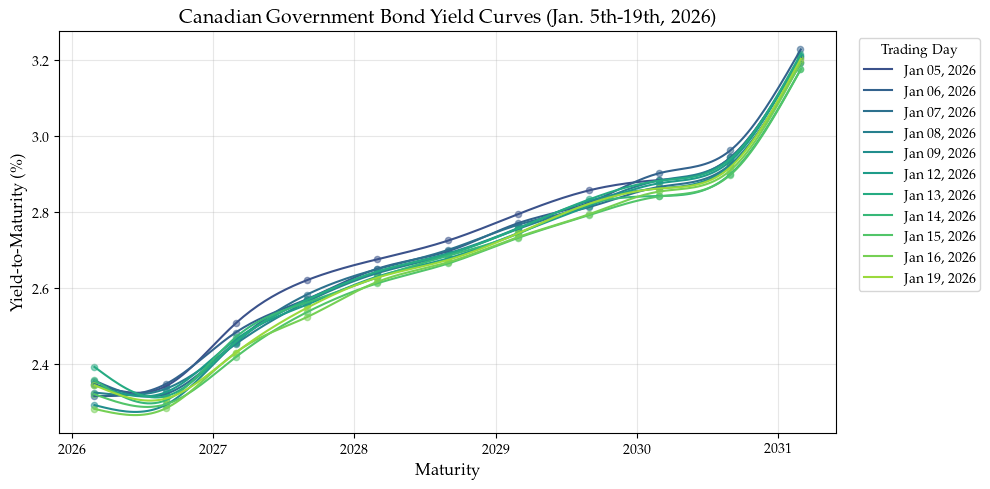

In [47]:
fig, axs = plt.subplots(figsize=(10, 5))
trading_dates = np.sort(bond_data_df["Date"].unique()) 
vals = np.linspace(0.25, 0.85, len(trading_dates))
cmap = dict(zip(trading_dates, [plt.cm.viridis(v) for v in vals]))

for date in bond_data_df['Date'].unique():
    
    bond_subset = bond_data_df[bond_data_df['Date'] == date]
    maturities = bond_subset['Final Coupon Date']

    x = (maturities - date).dt.days / 365  
    y = 100 * bond_subset['Yield to Maturity']  
    
    # Interpolate using natural cubic spline:
    cs = CubicSpline(x, y, bc_type='natural')
    x_smooth = np.linspace(x.min(), x.max(), 200)
    y_smooth = cs(x_smooth)
    
    # Convert (smoothed) year fraction from date to corresponding maturity:
    date = pd.Timestamp(date)
    maturity_smooth = date + pd.to_timedelta(x_smooth * 365.25, unit="D")
    
    axs.scatter(maturities, y, s=20, alpha=0.5, color=cmap[date])
    axs.plot(maturity_smooth, y_smooth, label=date.strftime('%b %d, %Y'), color=cmap[date])    
    
axs.set_xlabel('Maturity', fontsize=12)
axs.set_ylabel('Yield-to-Maturity (\%)', fontsize=12)
axs.set_title('Canadian Government Bond Yield Curves (Jan. 5th-19th, 2026)', fontsize=14)
axs.legend(title='Trading Day', bbox_to_anchor=(1.02, 1), loc='upper left')
axs.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

________________________________________

In [48]:
bond_data_df


,ISIN,Date,Face Value,Coupon Rate,Coupon Payment,Quoted Price,Clean Price,Accrued Interest,Dirty Price,Maturity Date,Coupon Start Date,Final Coupon Date,Yield to Maturity
0,CA135087L518,2026-01-05 22:44:00,1000,0.0025,2.5,99.700,997.00,0.863014,997.863014,2026-03-01,2021-03-01,2026-02-28,0.023473
1,CA135087L518,2026-01-06 22:44:00,1000,0.0025,2.5,99.710,997.10,0.869863,997.969863,2026-03-01,2021-03-01,2026-02-28,0.023166
2,CA135087L518,2026-01-07 22:44:00,1000,0.0025,2.5,99.710,997.10,0.876712,997.976712,2026-03-01,2021-03-01,2026-02-28,0.023573
3,CA135087L518,2026-01-08 22:44:00,1000,0.0025,2.5,99.720,997.20,0.883562,998.083562,2026-03-01,2021-03-01,2026-02-28,0.023257
4,CA135087L518,2026-01-09 22:44:00,1000,0.0025,2.5,99.730,997.30,0.890411,998.190411,2026-03-01,2021-03-01,2026-02-28,0.022928
...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,CA135087T792,2026-01-13 22:44:00,1000,0.0275,27.5,98.838,988.38,0.000000,988.380000,2031-03-01,2026-03-01,2031-02-28,0.032162
117,CA135087T792,2026-01-14 22:44:00,1000,0.0275,27.5,99.033,990.33,0.000000,990.330000,2031-03-01,2026-03-01,2031-02-28,0.031760
118,CA135087T792,2026-01-15 22:44:00,1000,0.0275,27.5,99.043,990.43,0.000000,990.430000,2031-03-01,2026-03-01,2031-02-28,0.031757
119,CA135087T792,2026-01-16 22:44:00,1000,0.0275,27.5,98.968,989.68,0.000000,989.680000,2031-03-01,2026-03-01,2031-02-28,0.031937


## **(b) Spot Curve Construction**

In this section, we construct the market spot curve on each trading day by bootstrapping the prices of our 10 considered bonds with staggered maturities.

We consider the $N$ coupon payment dates $t_0 < \cdots < t_{N} < T$ associated to the longest dated bond and let the final coupon date of bond $i$ be indexed by $N_i$, i.e. the **Final Coupon Date** of bond $i$ is $t_{N_i}$. This is valid as, given our choice of bonds, we have that the set of coupon dates of the longest dated bond contains all coupon dates of the earlier dated bonds. We let $R_i$ denote the (annual) **Coupon Rate** and hence have the annual **Coupon Payment** $C_i := F \cdot R_i$ where $F$ denotes the **Face Value** of the bond (note that all bonds selected share a common face value $F = 1000\, \mathrm{CAD}$). For a given trading day $t\in (t_{N_1-1}, t_{N_1}]$ (all considered trading days lie in this window), for each $j\geq N_1$ we denote the **spot rate** at term $t_j$ at time $t$ by $r(t, t_j)$ and can compute each spot rate in an inductive fashion via the following bootstrap procedure:


$$
P_1(t) = \frac{C_1/2 + F}{(1 + r(t, t_{N_1}))^{\tau_{N_1}}},
$$
and, for $2\leq i\leq 11$,

$$
P_i(t) =  \sum_{j = N_1}^{N_i-1} \frac{C_i/2}{(1 + r(t, t_j))^{\tau_{j}}} + \frac{F + C_i/2}{(1 + r(t, t_{N_i}))^{\tau_{N_i}}},
$$

where $\tau_j := t_j - t$ and $P_i(t)$ denotes the dirty price of bond $i$ at time $t$. The explicit recursive relationship, assuming $r(t, t_j)$ is known for $j = N_1, \dots, N_i-1$, is then given by:
$$
r(t, t_{N_{i}})
=
\left(
\frac{F + C_i/2}{
P_i(t) - \displaystyle\sum_{j=N_1}^{N_i-1}
\frac{C_i/2}{(1 + r(t, t_j))^{\tau_j}}
}
\right)^{1/\tau_{N_i}} - 1.
$$


In [49]:
trading_dates = bond_data_df["Date"].unique()
coupon_dates = bond_data_df['Final Coupon Date'].unique()
spot_curves = np.zeros((len(trading_dates), len(coupon_dates)))

for i, date in enumerate(trading_dates):

    # Get termns to maturity for each coupon date from price observation date:
    remaining_coupon_dates = coupon_dates[coupon_dates > date]
    num_remaining_coupons = len(remaining_coupon_dates)
    tau = (remaining_coupon_dates - date).days / 365  
        
    # Get spot rate at first coupon date:
    first_bond_info = bond_data_df[(bond_data_df['Date'] == date) & (bond_data_df['Final Coupon Date'] == remaining_coupon_dates[0])].iloc[0]
        
    C = first_bond_info['Coupon Payment']  
    F = first_bond_info['Face Value']
    P = first_bond_info['Dirty Price']
        
    r1 = ((F + C/2) / P) ** (1/tau[0]) - 1
    
    # Calculate spot rates at subsequent coupon dates using bootstrapping:
    spot_curves[i, 0] = r1
    
    for j in range(1, num_remaining_coupons):
        
        # Get coupon payment and face value for bond maturing at remaining_coupon_dates[j]:
        bond_info = bond_data_df[(bond_data_df['Date'] == date) & (bond_data_df['Final Coupon Date'] == remaining_coupon_dates[j])].iloc[0]
        
        C = bond_info['Coupon Payment']  
        F = bond_info['Face Value']
        P = bond_info['Dirty Price']
        
        # Calculate present value of coupon payments discounted at previously calculated spot rates:
        PV_coupons = np.sum((C / 2) / (1 + spot_curves[i, :j]) ** (tau[:j]))
        residual = P - PV_coupons

        # Calculate spot rate at next date via bootstrap:
        spot_curves[i, j] = ((F + C/2) / residual) ** (1/tau[j]) - 1


##### **Plot Spot Curve**

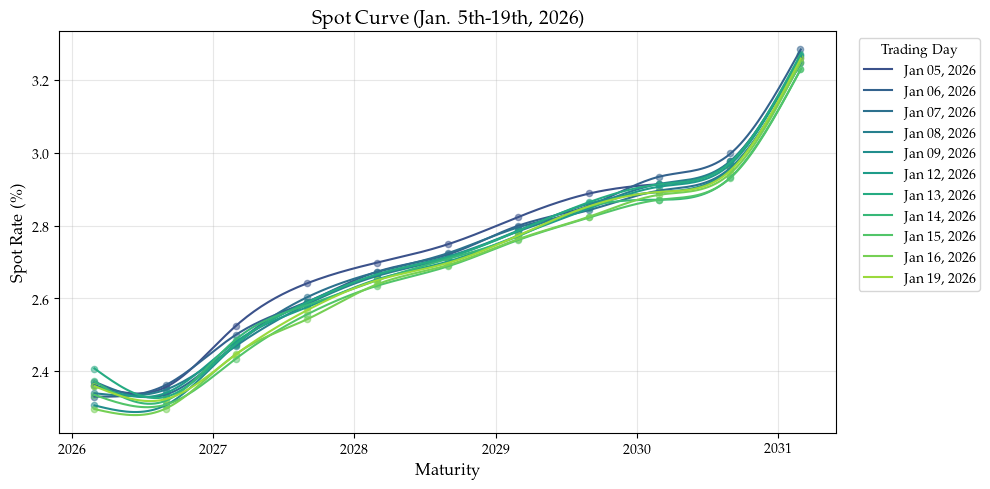

In [50]:
fig, axs = plt.subplots(figsize=(10, 5))
trading_dates = np.sort(bond_data_df["Date"].unique()) 
vals = np.linspace(0.25, 0.85, len(trading_dates))
cmap = dict(zip(trading_dates, [plt.cm.viridis(v) for v in vals]))

for i, date in enumerate(bond_data_df['Date'].unique()):
    
    bond_subset = bond_data_df[bond_data_df['Date'] == date]
    maturities = bond_subset['Final Coupon Date']

    x = (maturities - date).dt.days / 365  
    y = 100 * spot_curves[i,:]
    
    # Interpolate using natural cubic spline:
    cs = CubicSpline(x, y, bc_type='natural')
    x_smooth = np.linspace(x.min(), x.max(), 200)
    y_smooth = cs(x_smooth)
    
    # Convert (smoothed) year fraction from date to corresponding maturity:
    date = pd.Timestamp(date)
    maturity_smooth = date + pd.to_timedelta(x_smooth * 365.25, unit="D")
    
    # Plot spot curve on given date:
    axs.scatter(maturities, y, s=20, alpha=0.5, color=cmap[date])
    axs.plot(maturity_smooth, y_smooth, label=date.strftime('%b %d, %Y'), color=cmap[date])    
    
axs.set_xlabel('Maturity', fontsize=12)
axs.set_ylabel('Spot Rate (\%)', fontsize=12)
axs.set_title('Spot Curve (Jan. 5th-19th, 2026)', fontsize=14)
axs.legend(title='Trading Day', bbox_to_anchor=(1.02, 1), loc='upper left')
axs.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()